In [1]:
import datetime
import pathlib
import sys
import os

In [2]:
import xarray

In [3]:
import matplotlib

In [4]:
import torch.utils.data

In [5]:
# add cnrm code to python path
sys.path.append('/home/users/shaddad/prog/aids_fork/src/cnrm-unet/src')

In [6]:
import data as cnrm_data

In [7]:
#todo set up cordexbench training venv for notebook, add to repo

In [8]:
cordexbench_root = pathlib.Path('/gws/nopw/j04/mohc_shared/cordexbench')
print(cordexbench_root.is_dir())
cordexbench_root

True


PosixPath('/gws/nopw/j04/mohc_shared/cordexbench')

In [9]:
[d1 for d1 in cordexbench_root.iterdir() if d1.is_dir()]


[PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/ALPS_domain'),
 PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/NZ_domain'),
 PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain')]

In [10]:
domain_names = {
    'alps': 'ALPS_domain',
    'nz': 'NZ_domain',
    'sa': 'SA_domain',
}

In [11]:
domain_dirs = {domain_key: (cordexbench_root / domain_name) for domain_key,domain_name in domain_names.items()}
domain_dirs

{'alps': PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/ALPS_domain'),
 'nz': PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/NZ_domain'),
 'sa': PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain')}

In [12]:
!ls -R1  /gws/nopw/j04/mohc_shared/cordexbench/SA_domain

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain:
image_example_SA.png
test
train

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test:
end_century
historical
mid_century

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/end_century:
predictors
target

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/end_century/predictors:
imperfect
perfect

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/end_century/predictors/imperfect:
ACCESS-CM2_2080-2099.nc
NorESM2-MM_2080-2099.nc

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/end_century/predictors/perfect:
ACCESS-CM2_2080-2099.nc
NorESM2-MM_2080-2099.nc

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/end_century/target:

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/historical:
predictors
target

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/historical/predictors:
imperfect
perfect

/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/test/historical/predictors/imperfect:
ACCESS-CM2_1981-2000.nc
NorESM2-MM_198

In [13]:
list((domain_dirs['sa']/'train').iterdir())

[PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/ESD_pseudo_reality'),
 PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future')]

In [14]:
(list((domain_dirs['sa']/'train'/ 'Emulator_hist_future' / 'predictors').iterdir()),
list((domain_dirs['sa']/'train'/ 'Emulator_hist_future' / 'target').iterdir()))



([PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/predictors/ACCESS-CM2_1961-1980_2080-2099.nc'),
  PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/predictors/Static_fields.nc')],
 [PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/target/pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc')])

In [15]:
(list((domain_dirs['sa']/'train'/ 'ESD_pseudo_reality' / 'predictors').iterdir()),
list((domain_dirs['sa']/'train'/ 'ESD_pseudo_reality' / 'target').iterdir()))



([PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/ESD_pseudo_reality/predictors/ACCESS-CM2_1961-1980.nc'),
  PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/ESD_pseudo_reality/predictors/Static_fields.nc')],
 [PosixPath('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/ESD_pseudo_reality/target/pr_tasmax_ACCESS-CM2_1961-1980.nc')])

### Exploring ESD POseudo Reality training set

In [16]:
ESD_sa_train_dir = domain_dirs['sa']/'train'/ 'ESD_pseudo_reality'
ESD_sa_train_static_path = ESD_sa_train_dir / 'predictors' / 'Static_fields.nc'
ESD_sa_train_predictor_path = ESD_sa_train_dir / 'predictors' / 'ACCESS-CM2_1961-1980.nc'
ESD_sa_train_target_path = ESD_sa_train_dir / 'target' / 'pr_tasmax_ACCESS-CM2_1961-1980.nc'


In [17]:
esd_sa_train_predictor_ds = xarray.load_dataset(ESD_sa_train_predictor_path)
esd_sa_train_predictor_ds

<xarray.Dataset> Size: 112MB
Dimensions:    (time: 7300, bnds: 2, lat: 16, lon: 16)
Coordinates:
  * time       (time) datetime64[ns] 58kB 1961-01-01T12:00:00 ... 1980-12-31T...
  * lat        (lat) float64 128B -40.0 -38.0 -36.0 -34.0 ... -14.0 -12.0 -10.0
  * lon        (lon) float64 128B 11.0 13.0 15.0 17.0 ... 35.0 37.0 39.0 41.0
Dimensions without coordinates: bnds
Data variables: (12/16)
    time_bnds  (time, bnds) datetime64[ns] 117kB 1961-01-01 ... 1981-01-01
    t_500      (time, lat, lon) float32 7MB 259.6 260.2 260.9 ... 268.0 267.9
    t_700      (time, lat, lon) float32 7MB 273.9 275.0 276.7 ... 281.8 281.8
    t_850      (time, lat, lon) float32 7MB 281.1 281.9 283.3 ... 292.5 291.9
    u_500      (time, lat, lon) float32 7MB 32.73 31.41 29.55 ... -6.515 -4.869
    u_700      (time, lat, lon) float32 7MB 17.41 18.26 18.15 ... -3.172 -1.412
    ...         ...
    z_500      (time, lat, lon) float32 7MB 5.658e+03 5.676e+03 ... 5.853e+03
    z_700      (time, lat, lon) float32 7MB 3.024e+03 3.033e+03 ... 3.143e+03
    z_850      (time, lat, lon) float32 7MB 1.443e+03 1.447e+03 ... 1.506e+03
    q_500      (time, lat, lon) float32 7MB 0.0007726 0.000761 ... 0.001347
    q_700      (time, lat, lon) float32 7MB 0.002427 0.00215 ... 0.004654
    q_850      (time, lat, lon) float32 7MB 0.005501 0.005668 ... 0.008024
Attributes: (12/259)
    CDI:                  Climate Data Interface version 1.9.8 (https://mpime...
    history:              Thu Sep 25 10:04:17 2025: cdo mergetime 2deg_ccam_a...
    source:               CSIRO conformal-cubic model. Input file: ccam_8.km....
    Conventions:          CF-1.11
    title:                CCAM simulation data
    il:                   192
    ...                   ...
    ateb_ac_deltat:       1.0
    ateb_ac_heatcap:      10.0
    ateb_acfactor:        2.0
    ateb_alpha:           1.0
    ateb_lwintmeth:       2
    ateb_cvcoeffmeth:     1

In [51]:
esd_sa_train_predictor_ds['u_500']['time'].min(), esd_sa_train_predictor_ds['u_500']['time'].max()

(<xarray.DataArray 'time' ()> Size: 8B
 array('1961-01-01T12:00:00.000000000', dtype='datetime64[ns]'),
 <xarray.DataArray 'time' ()> Size: 8B
 array('1980-12-31T12:00:00.000000000', dtype='datetime64[ns]'))

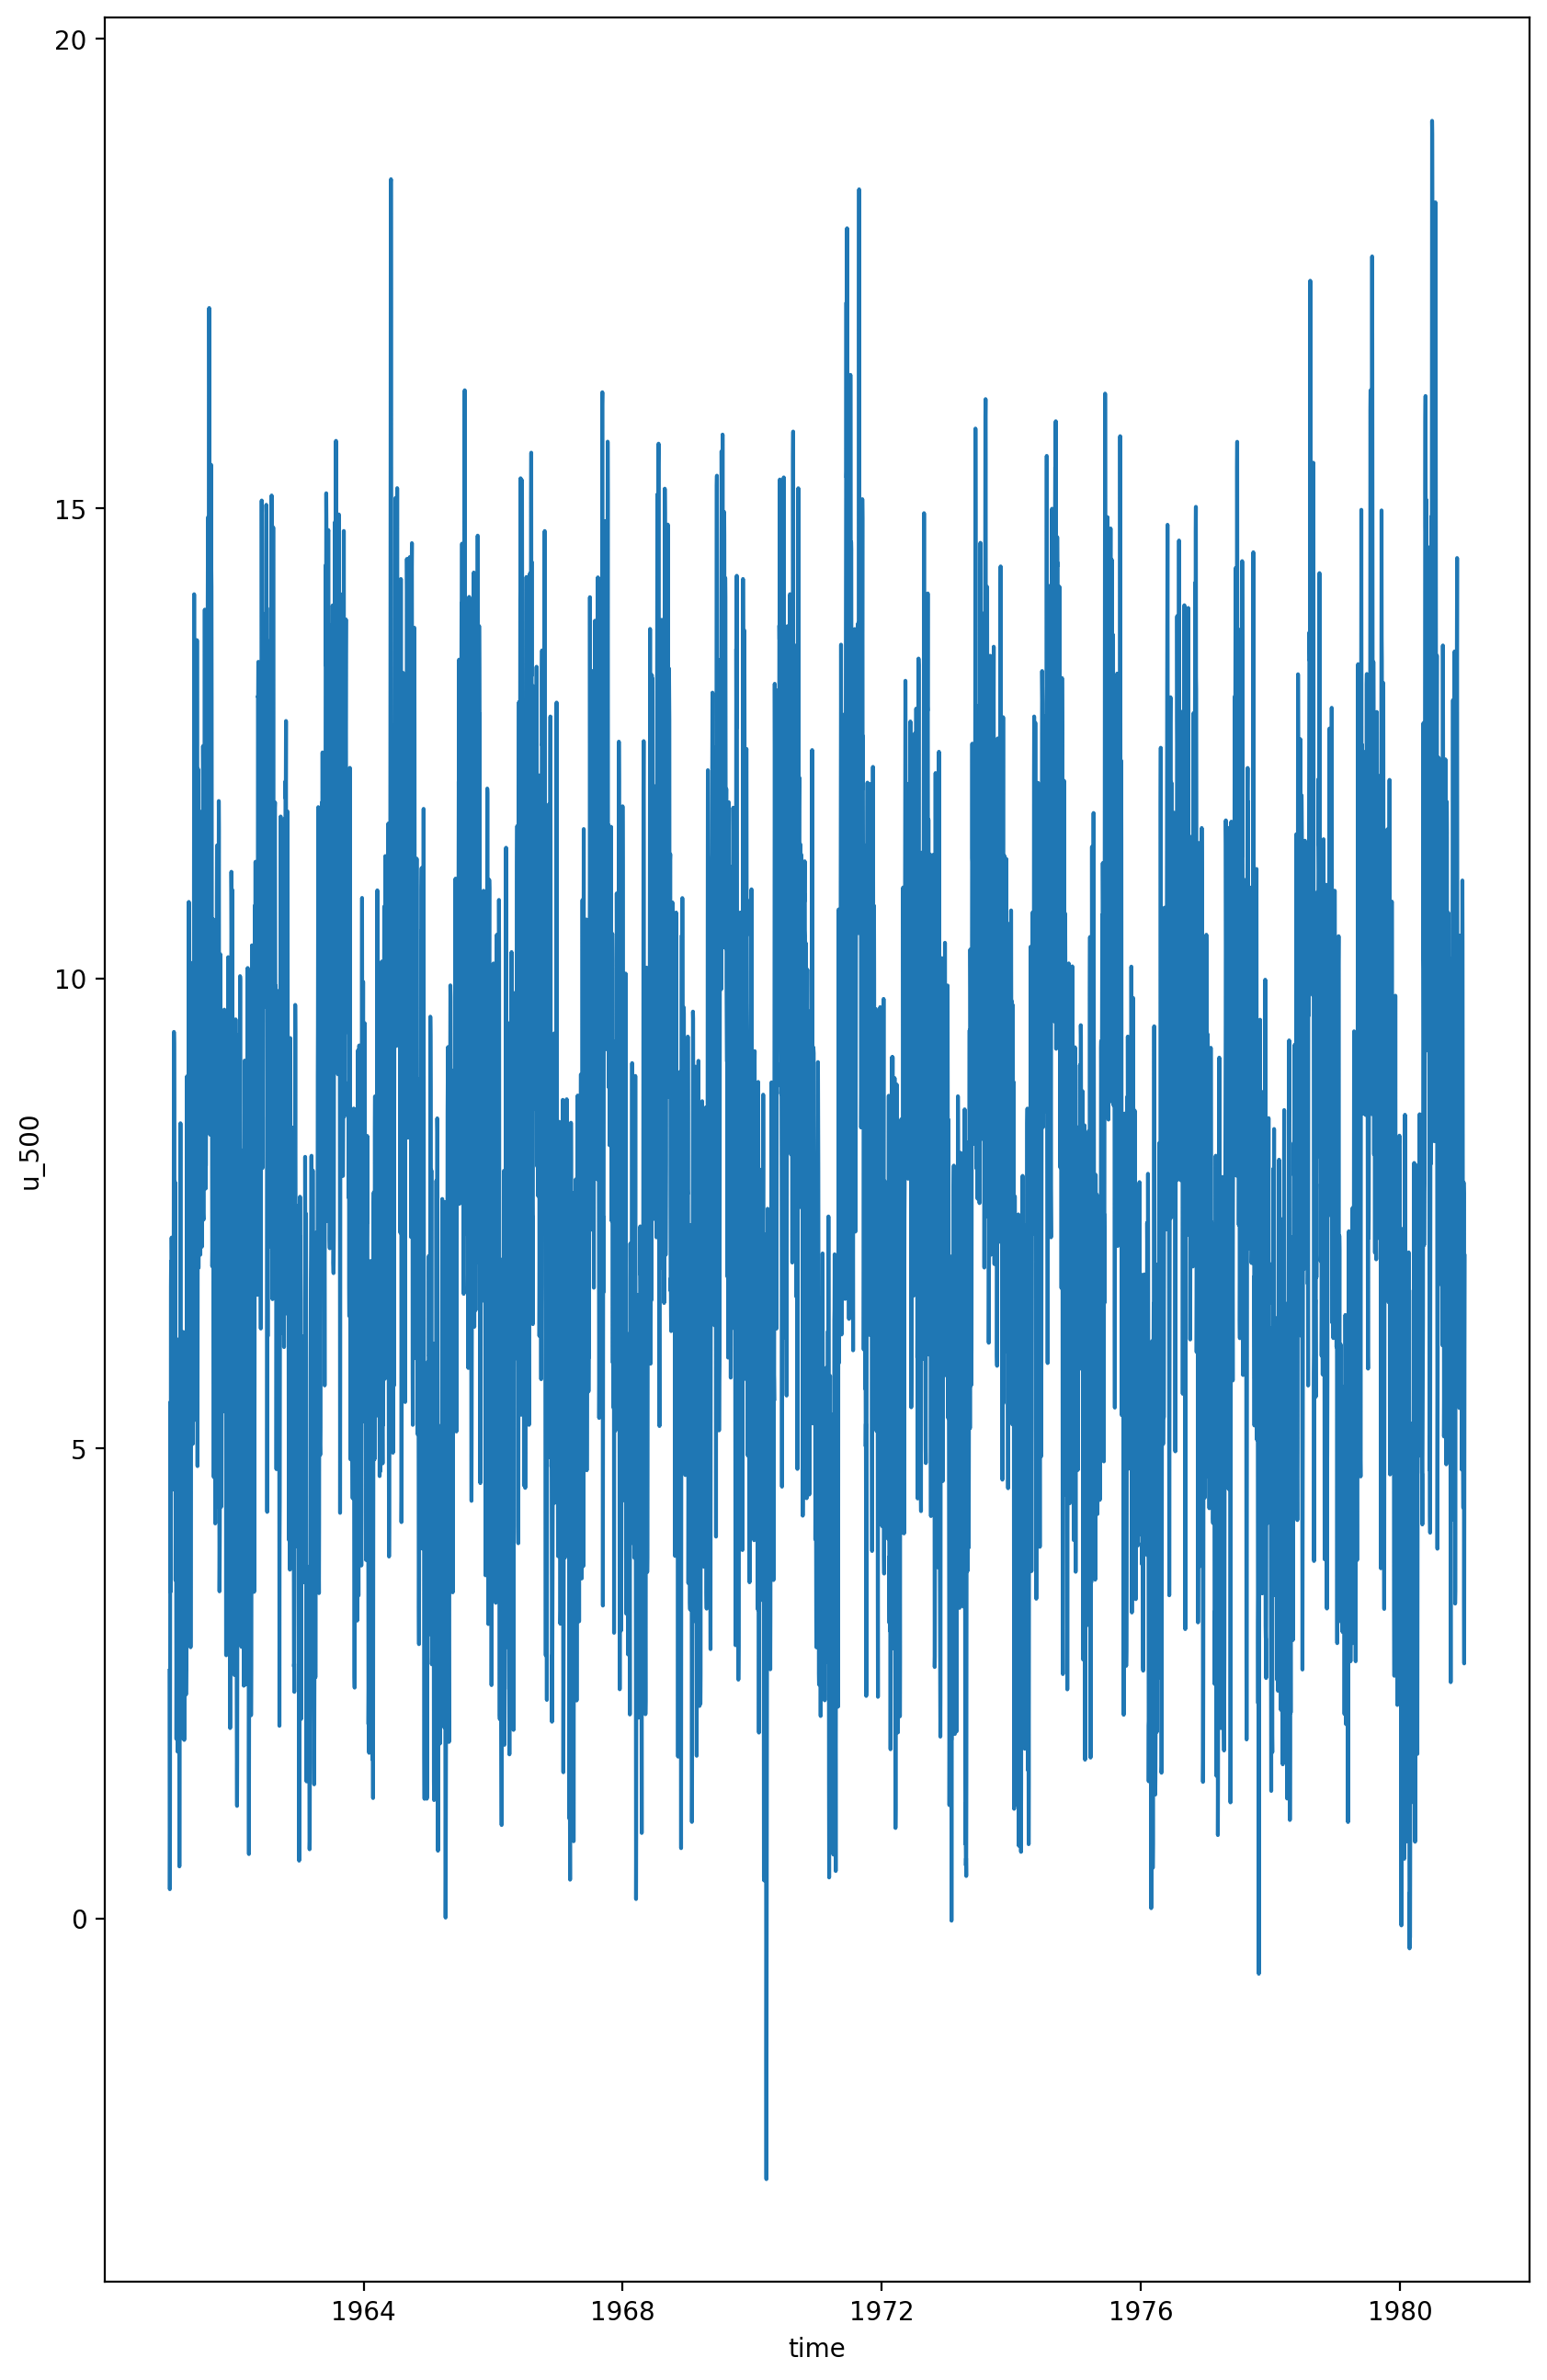

In [46]:
fig1 = matplotlib.pyplot.figure(figsize=(10,16),dpi=200)
ax1 = fig1.add_subplot(1,1,1)
esd_sa_train_predictor_ds['u_500'].mean(['lat','lon']).plot(ax=ax1)

In [19]:
my_array = esd_sa_train_predictor_ds['u_500'].mean(['lat','lon'])

In [20]:
esd_sa_train_static_ds = xarray.load_dataset(ESD_sa_train_static_path)
esd_sa_train_static_ds

<xarray.Dataset> Size: 370kB
Dimensions:    (lon: 301, bnds: 2, lat: 301, time: 31)
Coordinates:
  * lon        (lon) float32 1kB 11.0 11.1 11.2 11.3 ... 40.7 40.8 40.9 41.0
  * lat        (lat) float32 1kB -40.0 -39.9 -39.8 -39.7 ... -10.2 -10.1 -10.0
  * time       (time) datetime64[ns] 248B 1980-01-01T12:00:00 ... 1980-01-31T...
Dimensions without coordinates: bnds
Data variables:
    lon_bnds   (lon, bnds) float32 2kB 10.95 11.05 11.05 ... 40.95 40.95 41.05
    lat_bnds   (lat, bnds) float32 2kB -40.05 -39.95 -39.95 ... -10.05 -9.95
    time_bnds  (time, bnds) datetime64[ns] 496B 1980-01-01 ... 1980-02-01
    crs        int32 4B -2147483647
    orog       (lat, lon) float32 362kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes: (12/351)
    source:               CSIRO conformal-cubic model. Input file: ccam_8.km....
    Conventions:          CF-1.11
    title:                CCAM simulation data
    history:              Created on 2025-08-28 03:23:27
    il:                   192
    kl:                   35
    ...                   ...
    zomode:               0
    zoseaice:             0.0005
    expdesc:              CCAM model run
    version:              CCAM
    modeling_realm:       atmos
    grid:                 Unrotated latitude/longitude grid interpolated from...

In [21]:
esd_sa_train_target_ds = xarray.load_dataset(ESD_sa_train_target_path)
esd_sa_train_target_ds

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 7300, bnds: 2, lon: 128, lat: 128)
Coordinates:
  * time       (time) datetime64[ns] 58kB 1961-01-01T12:00:00 ... 1980-12-31T...
  * lon        (lon) float32 512B 20.5 20.6 20.7 20.8 ... 32.9 33.0 33.1 33.2
  * lat        (lat) float32 512B -34.7 -34.6 -34.5 -34.4 ... -22.2 -22.1 -22.0
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 117kB 1961-01-01 ... 1981-01-01
    lon_bnds   (lon, bnds) float32 1kB 20.45 20.55 20.55 ... 33.15 33.15 33.25
    lat_bnds   (lat, bnds) float32 1kB -34.75 -34.65 -34.65 ... -22.05 -21.95
    crs        int32 4B 1
    pr         (time, lat, lon) float64 957MB 0.2071 0.1544 ... 0.01088 0.001202
    tasmax     (time, lat, lon) float32 478MB 296.0 296.2 296.3 ... 306.8 306.8
Attributes: (12/259)
    CDI:                  Climate Data Interface version 1.9.8 (https://mpime...
    history:              Thu Sep 25 09:18:21 2025: cdo mergetime pr_tasmax_c...
    source:               CSIRO conformal-cubic model. Input file: ccam_8.km....
    Conventions:          CF-1.11
    title:                CCAM simulation data
    il:                   192
    ...                   ...
    ateb_ac_deltat:       1.0
    ateb_ac_heatcap:      10.0
    ateb_acfactor:        2.0
    ateb_alpha:           1.0
    ateb_lwintmeth:       2
    ateb_cvcoeffmeth:     1

In [22]:
 esd_sa_train_predictor_ds.time.min(),  esd_sa_train_predictor_ds.time.max()

(<xarray.DataArray 'time' ()> Size: 8B
 array('1961-01-01T12:00:00.000000000', dtype='datetime64[ns]'),
 <xarray.DataArray 'time' ()> Size: 8B
 array('1980-12-31T12:00:00.000000000', dtype='datetime64[ns]'))

In [23]:
ESD_sa_train_predictor_path.is_file()

True

In [24]:
stats_path = pathlib.Path('norm_stats,json')

In [25]:
sa_cordex_train = cnrm_data.CORDEXDataset(
    predictors_data_path=ESD_sa_train_predictor_path,
    predictors=['t_850','z_500','q_850'],
    target_data_path=ESD_sa_train_target_path,
    targets=['pr'],
    normalisation_stats_path=stats_path,
    is_train=True,
    reference_period_start=1970,
    reference_period_end=1975,
)

In [26]:
sa_cordex_train_loader = torch.utils.data.DataLoader(
        sa_cordex_train, batch_size=32, shuffle=True
)
    

In [27]:
[v1 for v1 in next(iter(sa_cordex_train_loader))]


[tensor([[[[-2.9335e+00, -2.9312e+00, -2.8012e+00,  ..., -1.5409e+00,
            -1.6133e+00, -1.6496e+00],
           [-2.5262e+00, -2.4871e+00, -2.3884e+00,  ..., -1.3422e+00,
            -1.4482e+00, -1.4603e+00],
           [-1.7517e+00, -1.6911e+00, -1.6197e+00,  ..., -1.1111e+00,
            -1.1595e+00, -1.1837e+00],
           ...,
           [ 6.3782e-01,  6.4987e-01,  8.2393e-01,  ...,  4.8538e-01,
             3.0674e-01,  7.3038e-02],
           [ 3.7950e-01,  4.0506e-01,  5.0712e-01,  ...,  3.2272e-01,
             1.0157e-01, -8.0659e-02],
           [ 2.5537e-01,  2.8892e-01,  2.7838e-01,  ...,  1.9364e-01,
            -8.5732e-02, -2.1010e-01]],
 
          [[-2.8307e+00, -2.8640e+00, -2.8906e+00,  ..., -2.2563e+00,
            -2.1609e+00, -2.0829e+00],
           [-2.1435e+00, -2.1472e+00, -2.1466e+00,  ..., -1.6752e+00,
            -1.6308e+00, -1.5979e+00],
           [-1.2758e+00, -1.2535e+00, -1.2202e+00,  ..., -9.9450e-01,
            -1.0109e+00, -1.0276e+00],


In [28]:
!ls -R1 /home/users/shaddad/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future

/home/users/shaddad/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future:
predictors
target

/home/users/shaddad/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/predictors:
ACCESS-CM2_1961-1980_2080-2099.nc
Static_fields.nc

/home/users/shaddad/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/target:
pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc


### training the model


In [29]:
#todo create unet model


In [30]:
#todo define hyperparameters

In [31]:
# todo do data transformations

In [32]:
# todo link to mlflow

In [33]:
#todo create mlflow experiment

In [34]:
# todo setup train stuff 

In [35]:
# todo run training loop

In [36]:
#todo run ionference on model

In [37]:
# todo pyproject file for unet env for installing source and dependencies, creatE PR with notebooks, env and pyprpject

In [38]:
# todo next notebook - load model from mmlflow and run inference , visualise results

In [39]:
#todo next notebook - compare results to baseline

In [40]:
# todo:next notebook - hyperparameter tuning

In [41]:
# todo: train on multiple domains

In [42]:
# todo: nxt notebook - runinference and evaluate result based on various metrics, use scores and/or esmvaltool for evaluation

# what are the metrics for defining climate downscaler performance 

In [43]:
# todo: pyearthtools - 
# -  pyearthtools cordexbench data accessor
# - pet eda notebook
# - pet downscaler training (base cnn) - pytorch
# -> pet operators for custom elements - gamma dist scaler, loss function
# put the generic cordexbench stuff in main pyearthtools, put the custom loss etc stuff in the ai downscaling repo, to demonstrate ecosystem approach
# - pet pipeline for evaluation 
# how to run saved model with pyearthtools, consider wrapper for mlflow model#
# integration of scores, esmvaltool with pyearthtools
# is there an anemoi downscaler architecture which I can train to demonstrate pet/anemoi integration?
